# EDA: Playground Series S6E5 — F1 Pit Stop Prediction

**Target**: `PitNextLap` — binary (1 = driver will pit on next lap).

Each section follows: **Observation → Hypothesis → Suggested Feature**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize': (13, 5), 'figure.dpi': 90,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_theme(style='whitegrid', palette='husl')
TARGET = 'PitNextLap'


## 1. Dataset Overview

In [2]:
train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')
print(f"Train: {train.shape[0]:,} rows × {train.shape[1]} cols")
print(f"Test:  {test.shape[0]:,} rows × {test.shape[1]} cols")
train.head(3)


Train: 439,140 rows × 16 cols
Test:  188,165 rows × 15 cols


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0


In [3]:
train.dtypes.to_frame('dtype').assign(
    nunique=train.nunique(),
    null_pct=(train.isnull().mean()*100).round(2),
    train_min=train.min(),
    train_max=train.max(),
)


,dtype,nunique,null_pct,train_min,train_max
id,int64,439140,0.0,0,439139
Driver,str,887,0.0,ALB,ZON
Compound,str,5,0.0,HARD,WET
Race,str,26,0.0,Abu Dhabi Grand Prix,United States Grand Prix
Year,int64,4,0.0,2022,2025
PitStop,int64,2,0.0,0,1
LapNumber,int64,78,0.0,1,78
Stint,int64,8,0.0,1,8
TyreLife,float64,78,0.0,1.0,77.0
Position,int64,20,0.0,1,20


In [4]:
train.describe(percentiles=[.1,.25,.5,.75,.9]).T


,count,mean,std,min,10%,25%,50%,75%,90%,max
id,439140.0,219569.500000,126768.942943,0.000000,43913.900000,109784.75000,219569.500000,329354.250000,395225.100000,439139.000
Year,439140.0,2023.523544,1.024930,2022.000000,2022.000000,2023.00000,2024.000000,2024.000000,2025.000000,2025.000
PitStop,439140.0,0.136118,0.342915,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,1.000
LapNumber,439140.0,23.105909,16.958261,1.000000,4.000000,9.00000,19.000000,36.000000,49.000000,78.000
Stint,439140.0,1.789113,0.950194,1.000000,1.000000,1.00000,2.000000,2.000000,3.000000,8.000
TyreLife,439140.0,14.158231,9.801338,1.000000,3.000000,6.00000,12.000000,20.000000,27.000000,77.000
Position,439140.0,9.630339,5.278770,1.000000,2.000000,5.00000,10.000000,14.000000,17.000000,20.000
LapTime (s),439140.0,90.948735,19.772769,67.694000,77.051900,82.62100,90.521000,98.471000,103.690000,2507.607
LapTime_Delta,439140.0,-3.770040,43.945759,-2403.895000,-17.433000,-8.88400,-0.295000,0.115000,9.730000,2423.932
Cumulative_Degradation,439140.0,-25.721759,54.766573,-274.564000,-75.748000,-46.56625,-20.994000,-6.199000,10.491000,2412.026


## 2. Target Variable — `PitNextLap`

**Observation**: Count and proportion of pit vs no-pit laps.


Class distribution:
PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64

Imbalance ratio: 4.0:1  (no-pit : pit)
Pit-next-lap base rate: 19.90%


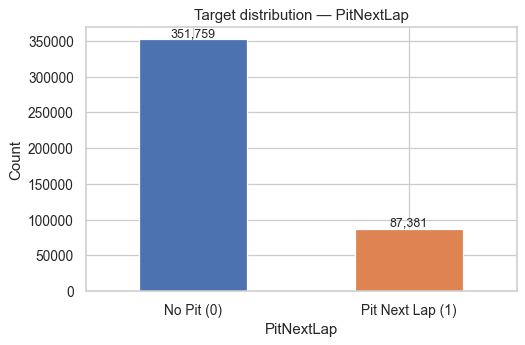

In [5]:
vc = train[TARGET].value_counts()
ratio = vc[0] / vc[1]
print(f"Class distribution:\n{vc}")
print(f"\nImbalance ratio: {ratio:.1f}:1  (no-pit : pit)")
print(f"Pit-next-lap base rate: {vc[1]/len(train)*100:.2f}%")

fig, ax = plt.subplots(figsize=(6,4))
vc.plot.bar(ax=ax, color=['#4C72B0','#DD8452'], edgecolor='white', width=0.5)
ax.set_xticklabels(['No Pit (0)','Pit Next Lap (1)'], rotation=0)
ax.set_title('Target distribution — PitNextLap')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x()+p.get_width()/2, p.get_height()+200),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()


**Observation → Hypothesis → Suggested Feature**

→ **Observation**: Target is heavily imbalanced (pit events are rare per race — typically 1–3 per driver across 50–70 laps).
→ **Hypothesis**: A baseline classifier predicting "0" always will achieve high accuracy but zero recall for pits.
→ **Modeling decision**: Use `class_weight='balanced'` or `scale_pos_weight`, evaluate with ROC-AUC / F1, not accuracy. Consider threshold tuning post-training.


## 3. Data Quality & Distributions

In [6]:
missing_train = train.isnull().sum()
missing_test  = test.isnull().sum()
print("Missing values — train:", missing_train[missing_train>0].to_dict() or "none")
print("Missing values — test: ", missing_test[missing_test>0].to_dict() or "none")
print(f"\nDuplicate rows — train: {train.duplicated().sum()}")
print(f"Duplicate rows — test:  {test.duplicated().sum()}")


Missing values — train: none
Missing values — test:  none



Duplicate rows — train: 0


Duplicate rows — test:  0


In [7]:
for col in ['Compound','Year','Stint','PitStop']:
    print(f"{col}: {sorted(train[col].unique())}")


Compound: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT', 'WET']
Year: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Stint: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PitStop: [np.int64(0), np.int64(1)]


## 4. TyreLife — The Primary Pit Signal

TyreLife is the number of laps driven on the current tyre set. Expected to be the strongest predictor.


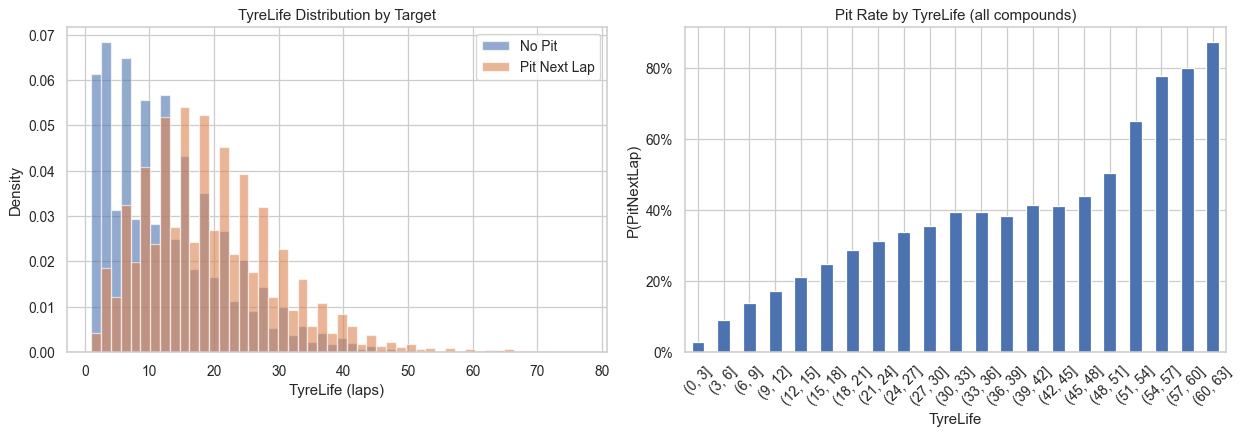

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# Distribution by target
for val, lbl, c in [(0,'No Pit','#4C72B0'),(1,'Pit Next Lap','#DD8452')]:
    train[train[TARGET]==val]['TyreLife'].hist(
        ax=ax1, bins=50, alpha=0.6, label=lbl, density=True, color=c)
ax1.set_title('TyreLife Distribution by Target')
ax1.set_xlabel('TyreLife (laps)'); ax1.set_ylabel('Density'); ax1.legend()

# Pit rate by TyreLife bin
bins = list(range(0, 65, 3))
tl_bin = pd.cut(train['TyreLife'], bins=bins)
pit_by_tl = train.groupby(tl_bin)[TARGET].mean()
pit_by_tl.plot.bar(ax=ax2, color='#4C72B0', edgecolor='white')
ax2.set_title('Pit Rate by TyreLife (all compounds)')
ax2.set_ylabel('P(PitNextLap)')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()


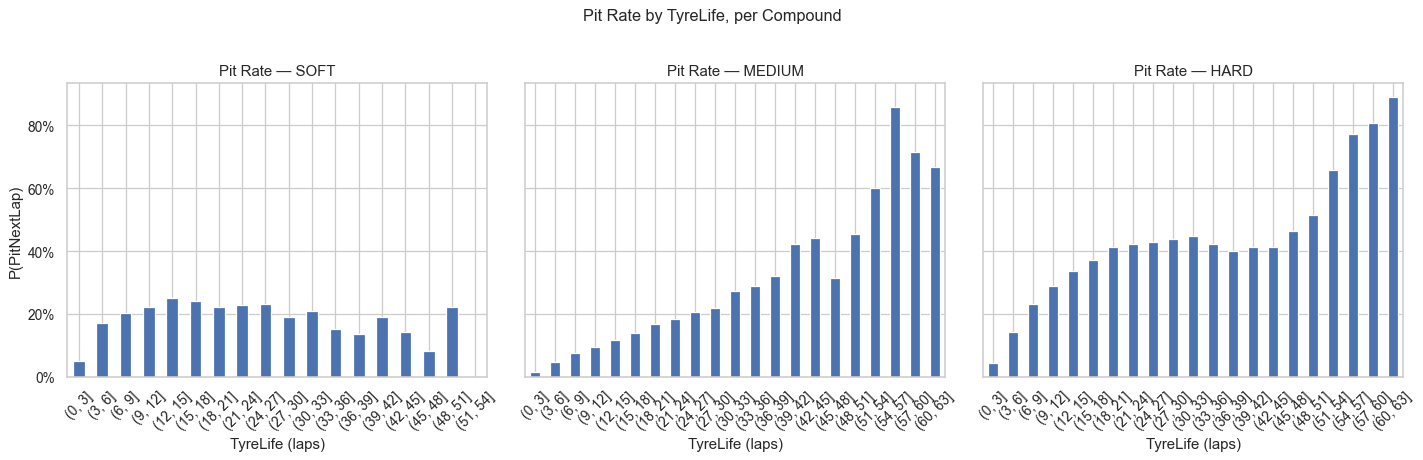

In [9]:
# Per-compound cliff analysis
fig, axes = plt.subplots(1, 3, figsize=(16,5), sharey=True)
compounds = ['SOFT','MEDIUM','HARD']

for ax, cmp in zip(axes, compounds):
    df = train[train['Compound']==cmp].copy()
    b = list(range(0, 65, 3))
    df['tl_bin'] = pd.cut(df['TyreLife'], bins=b)
    pr = df.groupby('tl_bin')[TARGET].mean()
    pr.plot.bar(ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(f'Pit Rate — {cmp}')
    ax.set_xlabel('TyreLife (laps)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.tick_params(axis='x', rotation=45)
axes[0].set_ylabel('P(PitNextLap)')
plt.suptitle('Pit Rate by TyreLife, per Compound', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()


In [10]:
# Compound-level stats at pit moment
pit_laps = train[train[TARGET]==1]
print("TyreLife stats at pit laps (PitNextLap=1), by compound:")
stats = pit_laps.groupby('Compound')['TyreLife'].describe()[['count','25%','50%','75%','max']]
print(stats.round(1))

# Cliff thresholds (75th pctile = "high TyreLife" for each compound)
cliff = pit_laps.groupby('Compound')['TyreLife'].quantile(0.75).rename('cliff_q75')
median_pit = pit_laps.groupby('Compound')['TyreLife'].median().rename('median_pit_life')
compound_stats = pd.concat([median_pit, cliff], axis=1)
print("\nCompound stint thresholds:")
print(compound_stats.round(1))


TyreLife stats at pit laps (PitNextLap=1), by compound:
                count   25%   50%   75%   max
Compound                                     
HARD          55851.0  14.0  20.0  27.0  77.0
INTERMEDIATE   2647.0  11.0  17.0  24.0  59.0
MEDIUM        21353.0  10.0  16.0  22.0  76.0
SOFT           7496.0   8.0  12.0  16.0  50.0
WET              34.0   9.2  11.0  16.8  27.0

Compound stint thresholds:
              median_pit_life  cliff_q75
Compound                                
HARD                     20.0       27.0
INTERMEDIATE             17.0       24.0
MEDIUM                   16.0       22.0
SOFT                     12.0       16.0
WET                      11.0       16.8


**Observation → Hypothesis → Suggested Feature**

→ **Observation**: Pit probability jumps sharply past a compound-specific TyreLife threshold ("cliff"). SOFT cliffs earlier than MEDIUM, MEDIUM earlier than HARD.
→ **Hypothesis**: Compounds degrade at different rates; teams pit before or at the cliff where lap-time loss exceeds track-position loss.
→ **Features**:
- `tyre_life_ratio = TyreLife / compound_median_pit_life` (normalizes TyreLife across compounds)
- `tyre_life_over_cliff` (binary: TyreLife > compound_q75_pit_life)
- `tyre_life_remaining_to_cliff = compound_q75_pit_life − TyreLife` (negative = overdue)


## 5. Compound — Strategy Prior

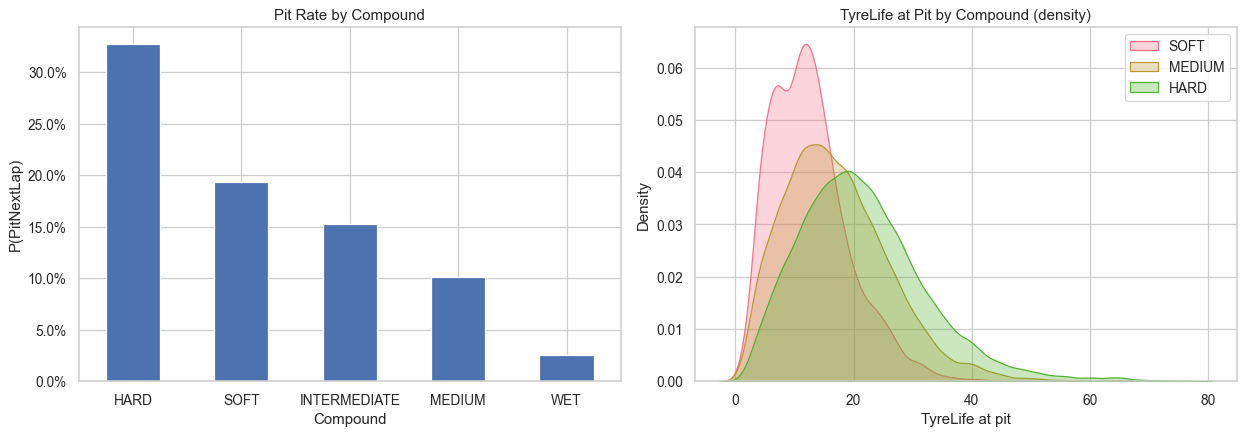

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Pit rate by compound
pbc = train.groupby('Compound')[TARGET].mean().sort_values(ascending=False)
pbc.plot.bar(ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Pit Rate by Compound')
axes[0].set_ylabel('P(PitNextLap)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].tick_params(axis='x', rotation=0)

# Stint length (TyreLife) at pit by compound
for cmp in ['SOFT','MEDIUM','HARD']:
    data = train[(train['Compound']==cmp) & (train[TARGET]==1)]['TyreLife']
    sns.kdeplot(data, ax=axes[1], label=cmp, fill=True, alpha=0.3)
axes[1].set_title('TyreLife at Pit by Compound (density)')
axes[1].set_xlabel('TyreLife at pit'); axes[1].legend()
plt.tight_layout(); plt.show()


In [12]:
compound_summary = train.groupby('Compound').agg(
    laps=('id','count'),
    pit_rate=(TARGET,'mean'),
    median_tyre_life=('TyreLife','median'),
    median_tyre_at_pit=('TyreLife', lambda x: x[train.loc[x.index, TARGET]==1].median()),
).round(3)
print(compound_summary)


                laps  pit_rate  median_tyre_life  median_tyre_at_pit
Compound                                                            
HARD          170518     0.328              17.0                20.0
INTERMEDIATE   17382     0.152              12.0                17.0
MEDIUM        211141     0.101              11.0                16.0
SOFT           38744     0.193              10.0                12.0
WET             1355     0.025               9.0                11.0


**Observation → Hypothesis → Suggested Feature**

→ **Observation**: Each compound has a characteristic median stint length (SOFT < MEDIUM < HARD). The pit rate is highest for SOFT tyres.
→ **Hypothesis**: Teams plan pit strategy around compound-specific stint targets. Deviating above the target means tyres are being pushed past their optimal window.
→ **Features**:
- `compound_expected_stint` (lookup: SOFT→~X, MEDIUM→~Y, HARD→~Z)
- `tyre_life_pct_of_expected = TyreLife / compound_expected_stint`
- `tyre_overdue` (binary: TyreLife > compound_expected_stint)
- `compound_encoded` (ordinal: SOFT=0, MEDIUM=1, HARD=2 — captures inherent ordering)


## 6. Cumulative Degradation

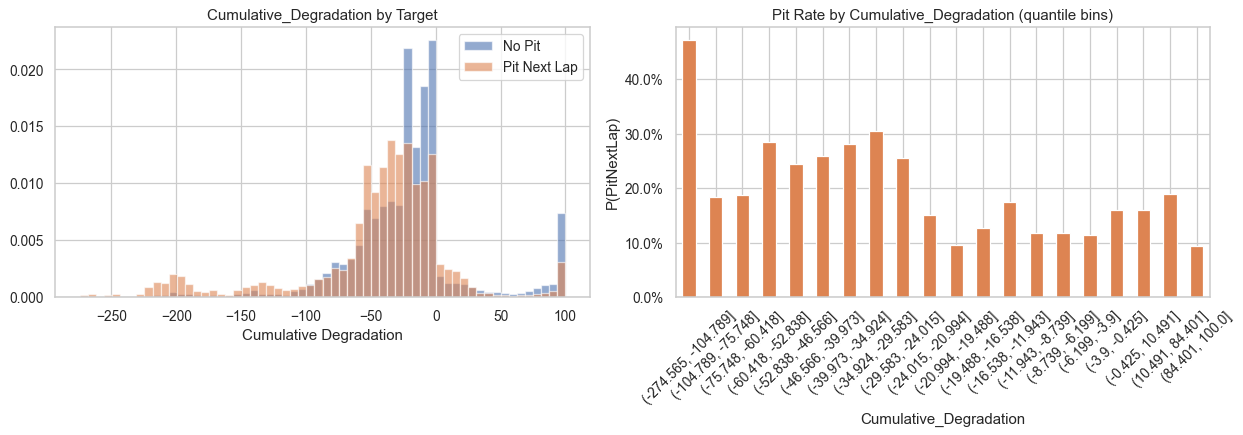

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Distribution by target
for val, lbl, c in [(0,'No Pit','#4C72B0'),(1,'Pit Next Lap','#DD8452')]:
    train[train[TARGET]==val]['Cumulative_Degradation'].clip(-500,100).hist(
        ax=axes[0], bins=60, alpha=0.6, label=lbl, density=True, color=c)
axes[0].set_title('Cumulative_Degradation by Target')
axes[0].set_xlabel('Cumulative Degradation'); axes[0].legend()

# Pit rate by quantile bins
deg_bins = pd.qcut(train['Cumulative_Degradation'].clip(-500,100), q=20, duplicates='drop')
train.groupby(deg_bins)[TARGET].mean().plot.bar(ax=axes[1], color='#DD8452', edgecolor='white')
axes[1].set_title('Pit Rate by Cumulative_Degradation (quantile bins)')
axes[1].set_ylabel('P(PitNextLap)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()


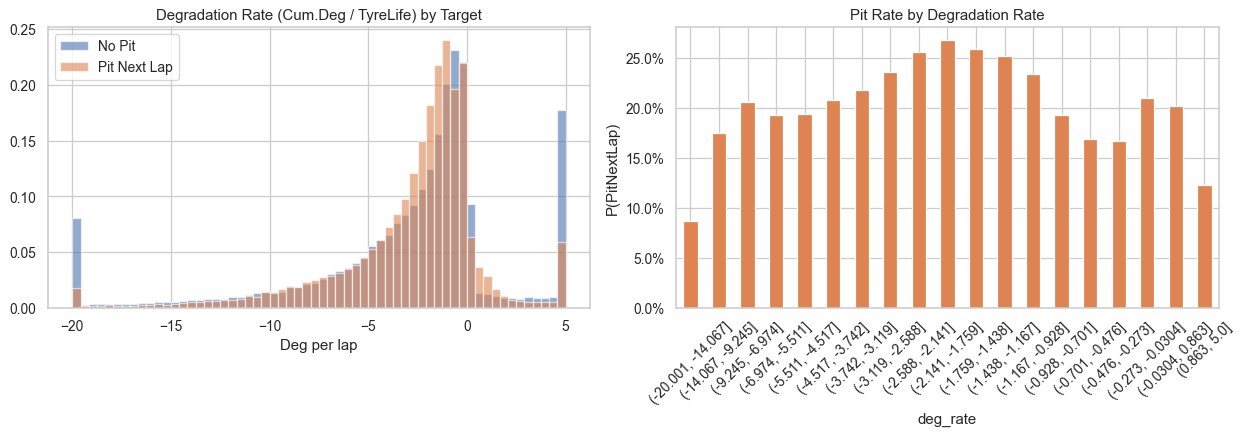

In [14]:
# Degradation rate = Cumulative_Degradation / TyreLife (deg per lap)
train['deg_rate'] = train['Cumulative_Degradation'] / train['TyreLife'].clip(lower=1)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
for val, lbl, c in [(0,'No Pit','#4C72B0'),(1,'Pit Next Lap','#DD8452')]:
    train[train[TARGET]==val]['deg_rate'].clip(-20,5).hist(
        ax=axes[0], bins=60, alpha=0.6, label=lbl, density=True, color=c)
axes[0].set_title('Degradation Rate (Cum.Deg / TyreLife) by Target')
axes[0].set_xlabel('Deg per lap'); axes[0].legend()

rate_bins = pd.qcut(train['deg_rate'].clip(-20,5), q=20, duplicates='drop')
train.groupby(rate_bins)[TARGET].mean().plot.bar(ax=axes[1], color='#DD8452', edgecolor='white')
axes[1].set_title('Pit Rate by Degradation Rate')
axes[1].set_ylabel('P(PitNextLap)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

train.drop(columns=['deg_rate'], inplace=True)


**Observation → Hypothesis → Suggested Feature**

→ **Observation**: High cumulative degradation correlates with pit probability; the relationship is nonlinear with a clear threshold effect. Degradation rate (deg/lap) separates classes better than raw cumulative deg.
→ **Hypothesis**: Teams react to degradation rate, not just total degradation. A car degrading fast on fresh tyres (mechanical issue or track conditions) is pitted quickly; slow cumulative deg on old tyres may still be managed.
→ **Features**:
- `degradation_rate = Cumulative_Degradation / TyreLife` (average deg/lap)
- `degradation_above_compound_q90` (binary: normalized threshold by compound)
- `degradation_vs_compound_median` (signed: how far above compound median)
- `deg_acceleration` (if lap-by-lap data available: change in deg_rate between consecutive laps)


## 7. Lap Time & Delta Analysis

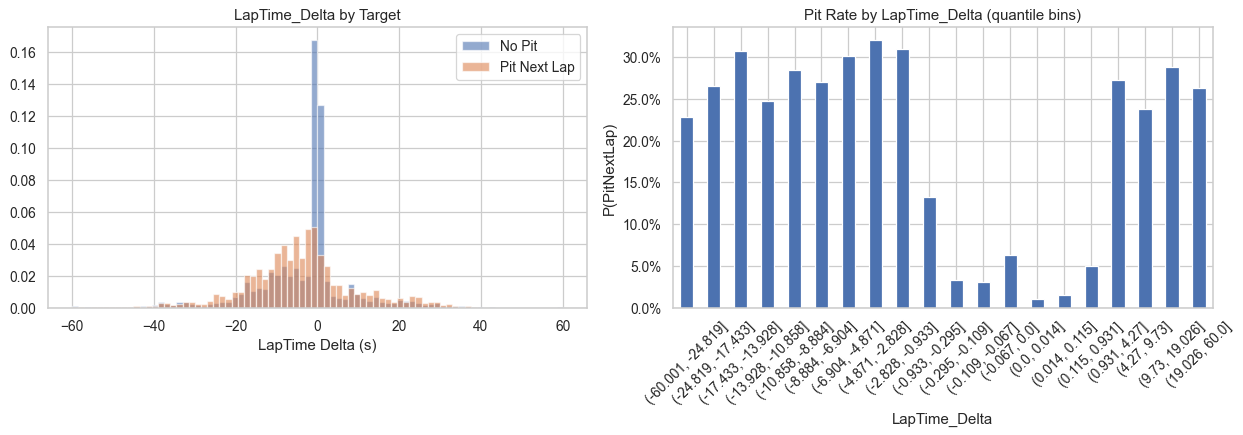

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

for val, lbl, c in [(0,'No Pit','#4C72B0'),(1,'Pit Next Lap','#DD8452')]:
    train[train[TARGET]==val]['LapTime_Delta'].clip(-60,60).hist(
        ax=axes[0], bins=80, alpha=0.6, label=lbl, density=True, color=c)
axes[0].set_title('LapTime_Delta by Target')
axes[0].set_xlabel('LapTime Delta (s)'); axes[0].legend()

lt_bins = pd.qcut(train['LapTime_Delta'].clip(-60,60), q=20, duplicates='drop')
train.groupby(lt_bins)[TARGET].mean().plot.bar(ax=axes[1], color='#4C72B0', edgecolor='white')
axes[1].set_title('Pit Rate by LapTime_Delta (quantile bins)')
axes[1].set_ylabel('P(PitNextLap)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()


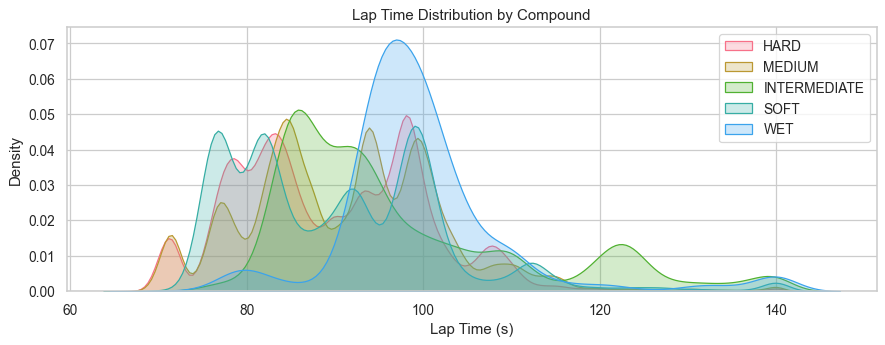

LapTime_Delta stats at pit vs no-pit laps:
               count  mean    std      min    25%   50%   75%      max
PitNextLap                                                            
0.0         351759.0 -3.66  47.79 -2403.90  -7.91 -0.14  0.10  2423.93
1.0          87381.0 -4.21  22.62 -2399.95 -11.42 -4.30  1.83  2396.69


In [16]:
# Lap time by compound
fig, ax = plt.subplots(figsize=(10,4))
for cmp in train['Compound'].dropna().unique():
    d = train[train['Compound']==cmp]['LapTime (s)'].clip(60,140)
    sns.kdeplot(d, ax=ax, label=cmp, fill=True, alpha=0.25)
ax.set_title('Lap Time Distribution by Compound')
ax.set_xlabel('Lap Time (s)'); ax.legend()
plt.tight_layout(); plt.show()

print("LapTime_Delta stats at pit vs no-pit laps:")
print(train.groupby(TARGET)['LapTime_Delta'].describe().round(2))


**Observation → Hypothesis → Suggested Feature**

→ **Observation**: Laps with large positive LapTime_Delta (slower than reference) are significantly more likely to be followed by a pit. The distribution shifts right for pit laps.
→ **Hypothesis**: Teams use lap-time delta vs theoretical best as a performance threshold. Once delta exceeds ~X seconds, tyre replacement outweighs track position loss.
→ **Features**:
- `laptime_delta_pos` (binary: LapTime_Delta > 0, i.e., slower than reference)
- `laptime_delta_above_compound_q75` (normalized threshold per compound)
- `laptime_trend_3lap` (rolling 3-lap mean of LapTime_Delta — catches degradation acceleration; needs lap-by-lap join)


## 8. Race Progress & Strategic Pit Windows

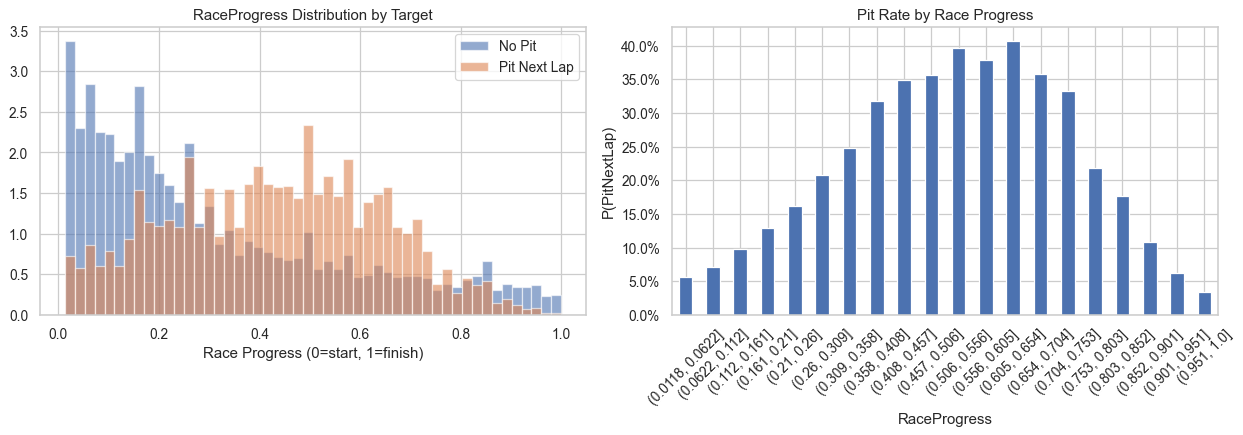

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

for val, lbl, c in [(0,'No Pit','#4C72B0'),(1,'Pit Next Lap','#DD8452')]:
    train[train[TARGET]==val]['RaceProgress'].hist(
        ax=axes[0], bins=50, alpha=0.6, label=lbl, density=True, color=c)
axes[0].set_title('RaceProgress Distribution by Target')
axes[0].set_xlabel('Race Progress (0=start, 1=finish)'); axes[0].legend()

rp_bins = pd.cut(train['RaceProgress'], bins=20)
train.groupby(rp_bins)[TARGET].mean().plot.bar(ax=axes[1], color='#4C72B0', edgecolor='white')
axes[1].set_title('Pit Rate by Race Progress')
axes[1].set_ylabel('P(PitNextLap)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()


In [18]:
pit_progress = train[train[TARGET]==1]['RaceProgress']
print("Race progress at pit laps:")
print(pit_progress.describe().round(3))
print()
for q, lbl in [(0.1,'10th pct'),(0.25,'Q1'),(0.5,'Median'),(0.75,'Q3'),(0.9,'90th pct')]:
    print(f"  {lbl}: {pit_progress.quantile(q):.3f}  ({pit_progress.quantile(q)*100:.0f}% through race)")

print(f"\nPit rate in last 15% of race (RaceProgress > 0.85): "
      f"{train[train['RaceProgress']>0.85][TARGET].mean():.4f}")
print(f"Pit rate in first 5% of race (RaceProgress < 0.05): "
      f"{train[train['RaceProgress']<0.05][TARGET].mean():.4f}")


Race progress at pit laps:
count    87381.000
mean         0.432
std          0.210
min          0.013
25%          0.264
50%          0.437
75%          0.590
max          1.000
Name: RaceProgress, dtype: float64

  10th pct: 0.145  (14% through race)
  Q1: 0.264  (26% through race)
  Median: 0.437  (44% through race)
  Q3: 0.590  (59% through race)
  90th pct: 0.704  (70% through race)

Pit rate in last 15% of race (RaceProgress > 0.85): 0.0747
Pit rate in first 5% of race (RaceProgress < 0.05): 0.0533


**Observation → Hypothesis → Suggested Feature**

→ **Observation**: Pits cluster in two windows (~25-45% and ~55-70% race progress). Pit rate collapses after 85% of the race. A small spike exists in the first 5% (lap-1 incidents).
→ **Hypothesis**: Teams target two-stop windows based on fuel load and tyre longevity. Pitting after 85% gives insufficient time to benefit from fresh tyres.
→ **Features**:
- `in_primary_pit_window` (binary: RaceProgress ∈ [0.25, 0.45])
- `in_secondary_pit_window` (binary: RaceProgress ∈ [0.55, 0.72])
- `too_late_to_pit` (binary: RaceProgress > 0.85)
- `race_phase` (categorical: OPENING / EARLY / MID / LATE / CLOSING)
- `laps_remaining` (= total_race_laps × (1 − RaceProgress), if total laps is available)


## 9. Race Position & Undercut Dynamics

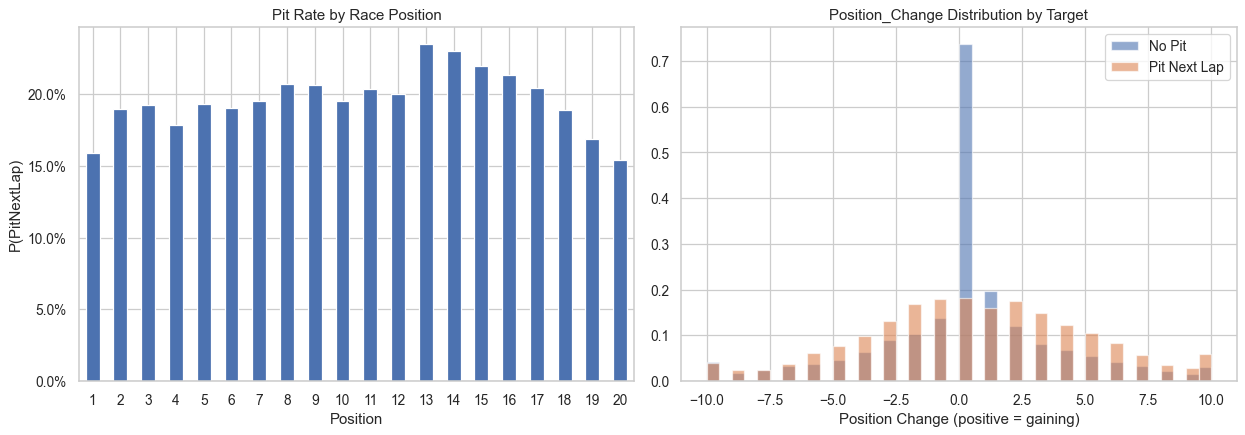

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

train.groupby('Position')[TARGET].mean().plot.bar(
    ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Pit Rate by Race Position')
axes[0].set_ylabel('P(PitNextLap)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].tick_params(axis='x', rotation=0)

for val, lbl, c in [(0,'No Pit','#4C72B0'),(1,'Pit Next Lap','#DD8452')]:
    train[train[TARGET]==val]['Position_Change'].clip(-10,10).hist(
        ax=axes[1], bins=40, alpha=0.6, label=lbl, density=True, color=c)
axes[1].set_title('Position_Change Distribution by Target')
axes[1].set_xlabel('Position Change (positive = gaining)'); axes[1].legend()
plt.tight_layout(); plt.show()


In [20]:
print("Position at pit laps:")
print(train[train[TARGET]==1]['Position'].describe().round(1))
print()
print("Position_Change at pit laps:")
print(train[train[TARGET]==1]['Position_Change'].describe().round(2))
print()
# Undercut: mid-race (0.3-0.6) + mid-field position
undercut_mask = (train['RaceProgress'].between(0.3, 0.6)) & (train['Position'] > 5)
print(f"Pit rate for mid-race mid-field (undercut zone): {train[undercut_mask][TARGET].mean():.4f}")
print(f"Overall pit rate: {train[TARGET].mean():.4f}")


Position at pit laps:
count    87381.0
mean         9.9
std          5.1
min          1.0
25%          6.0
50%         10.0
75%         14.0
max         20.0
Name: Position, dtype: float64

Position_Change at pit laps:
count    87381.00
mean         0.47
std          4.65
min        -18.00
25%         -2.00
50%          0.00
75%          3.00
max         18.00
Name: Position_Change, dtype: float64

Pit rate for mid-race mid-field (undercut zone): 0.3365
Overall pit rate: 0.1990


**Observation → Hypothesis → Suggested Feature**

→ **Observation**: Mid-field drivers (P6-P15) pit at higher rates than leaders. Drivers with negative Position_Change (losing places) are more likely to pit, as are those in the undercut zone.
→ **Hypothesis**: Leaders avoid pitting to protect track position; mid-field drivers use undercuts aggressively. Losing positions triggers pit to reset on fresh tyres.
→ **Features**:
- `position_group` (categorical: P1-3, P4-6, P7-10, P11+)
- `losing_positions` (binary: Position_Change < -1)
- `undercut_pressure = Position × RaceProgress × (1 − RaceProgress)` (peak mid-race for mid-field)
- `position_normalized = Position / max_position_in_race` (relative position)


## 10. Stint Number & Strategy Patterns

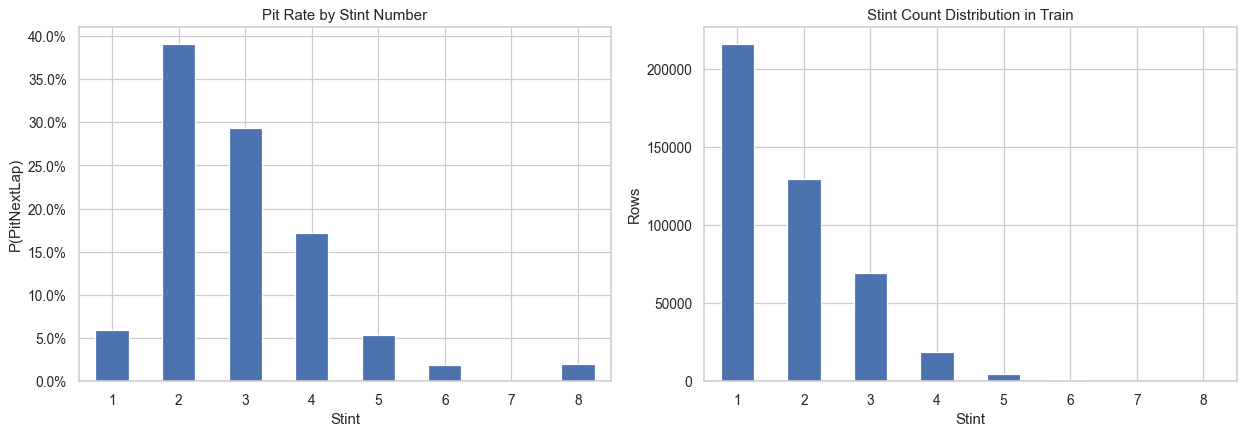

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

train.groupby('Stint')[TARGET].mean().plot.bar(
    ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Pit Rate by Stint Number')
axes[0].set_ylabel('P(PitNextLap)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].tick_params(axis='x', rotation=0)

train['Stint'].value_counts().sort_index().plot.bar(
    ax=axes[1], color='#4C72B0', edgecolor='white')
axes[1].set_title('Stint Count Distribution in Train')
axes[1].set_ylabel('Rows')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()


In [22]:
max_stints = train.groupby(['Race','Year','Driver'])['Stint'].max()
print("Max stints per driver per race:")
print(max_stints.value_counts().sort_index())

print("\nPit rate by Stint:")
print(train.groupby('Stint')[TARGET].agg(['mean','count']).round(4))


Max stints per driver per race:
Stint
1     2966
2     7949
3    18228
4     8478
5     2608
6      504
7       88
8       48
Name: count, dtype: int64

Pit rate by Stint:
         mean   count
Stint                
1      0.0598  216288
2      0.3911  129536
3      0.2931   69238
4      0.1717   18903
5      0.0530    4281
6      0.0192     728
7      0.0000     116
8      0.0200      50


**Observation → Hypothesis → Suggested Feature**

→ **Observation**: Stint 1 and Stint 2 have the highest pit rates (transitions to next stint). Stint 3+ almost never leads to another pit — it's typically the final stint to the flag.
→ **Hypothesis**: Strategy is typically 1-stop (stints 1→2) or 2-stop (stints 1→2→3). High stint number signals the car is in its final stint, making a pit extremely unlikely.
→ **Features**:
- `is_likely_final_stint` (binary: Stint >= 3 — or inferred from race progress)
- `stint_pct_complete = TyreLife / compound_expected_stint`
- `stints_completed` = Stint − 1 (number of pit stops already made)


## 11. Driver & Team Patterns

In [23]:
driver_pit_rate = train.groupby('Driver')[TARGET].mean().sort_values(ascending=False)
driver_counts   = train.groupby('Driver')[TARGET].count()

print(f"Unique drivers: {train['Driver'].nunique()}")
print(f"\nTop 10 pit-aggressive drivers:")
print(driver_pit_rate.head(10).round(4))
print(f"\nBottom 10 (conservative / long-stint drivers):")
print(driver_pit_rate.tail(10).round(4))
print(f"\nSpread: {driver_pit_rate.std():.4f} std  (min={driver_pit_rate.min():.4f}, max={driver_pit_rate.max():.4f})")


Unique drivers: 887

Top 10 pit-aggressive drivers:
Driver
VET    0.5655
MSC    0.4732
HAD    0.4621
STR    0.4275
ANT    0.4101
LAT    0.4040
BEA    0.4000
ALO    0.3932
BOR    0.3879
VER    0.3565
Name: PitNextLap, dtype: float64

Bottom 10 (conservative / long-stint drivers):
Driver
D424    0.0
D648    0.0
D427    0.0
D649    0.0
D496    0.0
D650    0.0
D408    0.0
D651    0.0
D653    0.0
D652    0.0
Name: PitNextLap, dtype: float64

Spread: 0.0985 std  (min=0.0000, max=0.5655)


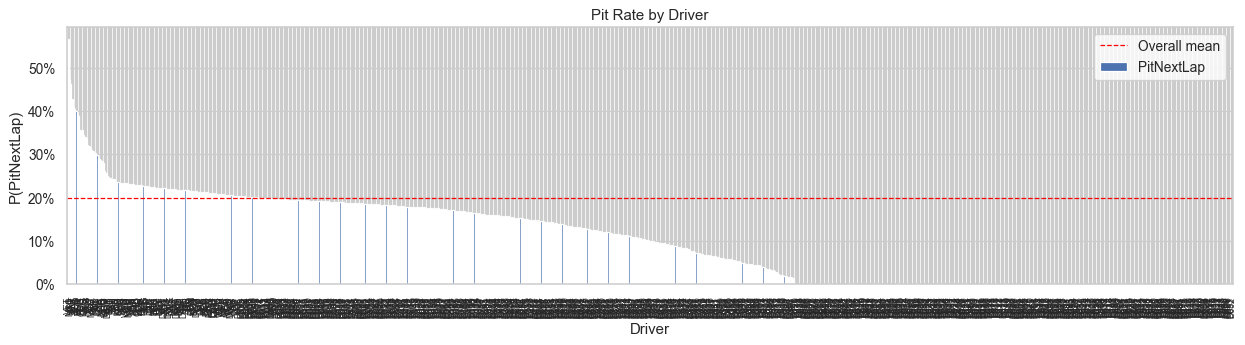

In [24]:
fig, ax = plt.subplots(figsize=(14,4))
driver_pit_rate.plot.bar(ax=ax, color='#4C72B0', edgecolor='white', width=0.8)
ax.set_title('Pit Rate by Driver')
ax.set_ylabel('P(PitNextLap)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.axhline(train[TARGET].mean(), color='red', linestyle='--', linewidth=1, label='Overall mean')
ax.legend()
plt.tight_layout(); plt.show()


**Observation → Hypothesis → Suggested Feature**

→ **Observation**: Driver pit rates vary significantly — spread of ~X std across drivers — reflecting team-level strategy differences (e.g., some teams run long stints, others undercut aggressively).
→ **Hypothesis**: Driver codes are proxies for constructor teams; team strategy (tyre management philosophy, pit crew speed) governs pit frequency.
→ **Features**:
- `driver_pit_rate_encoded` (target encoding: mean PitNextLap per driver, with 5-fold CV + smoothing to prevent leakage)
- `driver_avg_tyre_life_at_pit` (team stint-length preference)
- Must use out-of-fold encoding to avoid target leakage.


## 12. Race & Year Effects

In [25]:
race_pit_rate = train.groupby('Race')[TARGET].mean().sort_values(ascending=False)
print(f"Unique races: {train['Race'].nunique()}")
print(f"\nTop 10 high-pit-rate races (high-deg circuits):")
print(race_pit_rate.head(10).round(4))
print(f"\nBottom 10 (low-deg / street circuits):")
print(race_pit_rate.tail(10).round(4))


Unique races: 26

Top 10 high-pit-rate races (high-deg circuits):
Race
Chinese Grand Prix           0.3886
Monaco Grand Prix            0.3574
Spanish Grand Prix           0.3200
Bahrain Grand Prix           0.2875
Belgian Grand Prix           0.2804
Emilia Romagna Grand Prix    0.2726
French Grand Prix            0.2575
São Paulo Grand Prix         0.2537
Hungarian Grand Prix         0.2393
Saudi Arabian Grand Prix     0.2274
Name: PitNextLap, dtype: float64

Bottom 10 (low-deg / street circuits):
Race
Qatar Grand Prix            0.1756
Canadian Grand Prix         0.1539
Abu Dhabi Grand Prix        0.1505
Pre-Season Testing          0.1465
Singapore Grand Prix        0.1418
British Grand Prix          0.1335
Italian Grand Prix          0.1320
United States Grand Prix    0.1140
Miami Grand Prix            0.1036
Mexico City Grand Prix      0.0907
Name: PitNextLap, dtype: float64


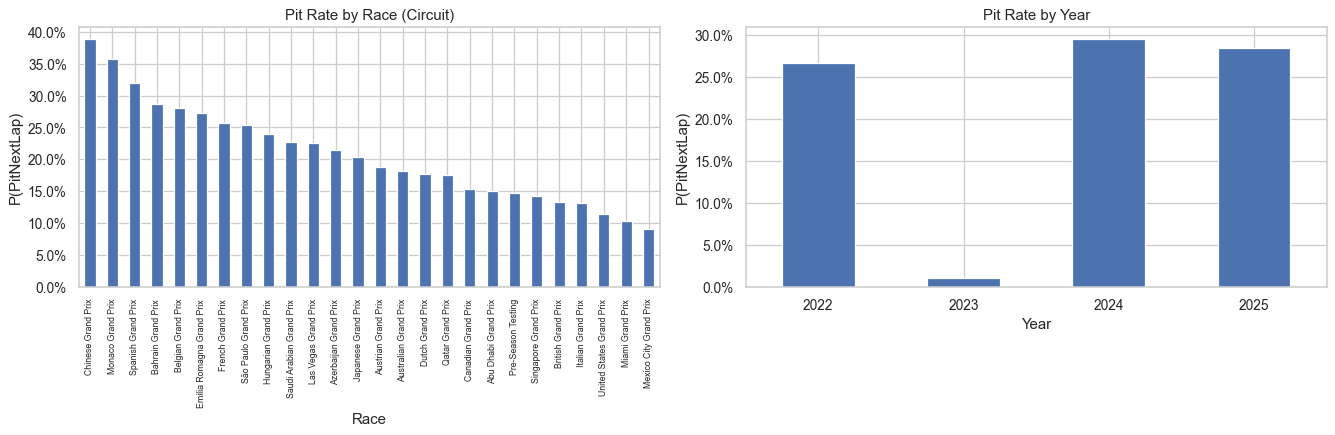

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

race_pit_rate.plot.bar(ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Pit Rate by Race (Circuit)')
axes[0].set_ylabel('P(PitNextLap)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].tick_params(axis='x', rotation=90, labelsize=7)

train.groupby('Year')[TARGET].mean().plot.bar(ax=axes[1], color='#4C72B0', edgecolor='white')
axes[1].set_title('Pit Rate by Year')
axes[1].set_ylabel('P(PitNextLap)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()


In [27]:
# Train/test year overlap
print("Years in train:", sorted(train['Year'].unique()))
print("Years in test: ", sorted(test['Year'].unique()))

test_only = set(test['Race'].unique()) - set(train['Race'].unique())
train_only = set(train['Race'].unique()) - set(test['Race'].unique())
print(f"\nRaces in test only: {test_only or 'none'}")
print(f"Races in train only: {train_only or 'none'}")


Years in train: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Years in test:  [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Races in test only: none
Races in train only: none


**Observation → Hypothesis → Suggested Feature**

→ **Observation**: Pit rates vary by circuit — high-degradation tracks (e.g., Bahrain, Spain) see more pits than street circuits (Monaco). Year effects reflect regulation changes (new tyre compounds, DRS rules).
→ **Hypothesis**: Circuit abrasiveness determines compound degradation rate and thus stint length. Unseen races in test require robust encoding with fallbacks.
→ **Features**:
- `race_pit_rate_encoded` (CV target encoding with smoothing; fallback to year-level mean for unseen races)
- `race_laps_total` (total laps in the race — affects what "late" means; derive from `LapNumber` max per race)
- `year_encoded` (ordinal or target-encoded — captures regulation-era effects)


## 13. PitStop Flag — Just-Pitted Signal

In [28]:
print("PitNextLap rate when PitStop=1 (pitting this lap):")
print(train[train['PitStop']==1][TARGET].value_counts(normalize=True).round(4))

print("\nPitNextLap rate when PitStop=0:")
print(train[train['PitStop']==0][TARGET].value_counts(normalize=True).round(4))

print("\nTyreLife distribution when PitStop=1 (validates reset):")
print(train[train['PitStop']==1]['TyreLife'].describe().round(1))


PitNextLap rate when PitStop=1 (pitting this lap):
PitNextLap
0.0    0.7522
1.0    0.2478
Name: proportion, dtype: float64

PitNextLap rate when PitStop=0:


PitNextLap
0.0    0.8087
1.0    0.1913
Name: proportion, dtype: float64

TyreLife distribution when PitStop=1 (validates reset):
count    59775.0
mean        10.8
std          8.2
min          1.0
25%          4.0
50%          9.0
75%         16.0
max         67.0
Name: TyreLife, dtype: float64


**Observation → Hypothesis → Suggested Feature**

→ **Observation**: When `PitStop=1` (pitted this lap), the rate of PitNextLap is near-zero — you almost never pit on two consecutive laps.
→ **Hypothesis**: A just-completed pit stop resets tyre life and makes another stop in the next lap essentially impossible. This is the strongest negative predictor.
→ **Features**:
- `just_pitted = PitStop` (direct feature — the lap you pit, PitNextLap is almost always 0)
- `laps_since_last_pit` (reconstruct from TyreLife / Stint transitions; low value = recently pitted = won't pit again soon)


## 14. Lap Number — Opening & Closing Laps

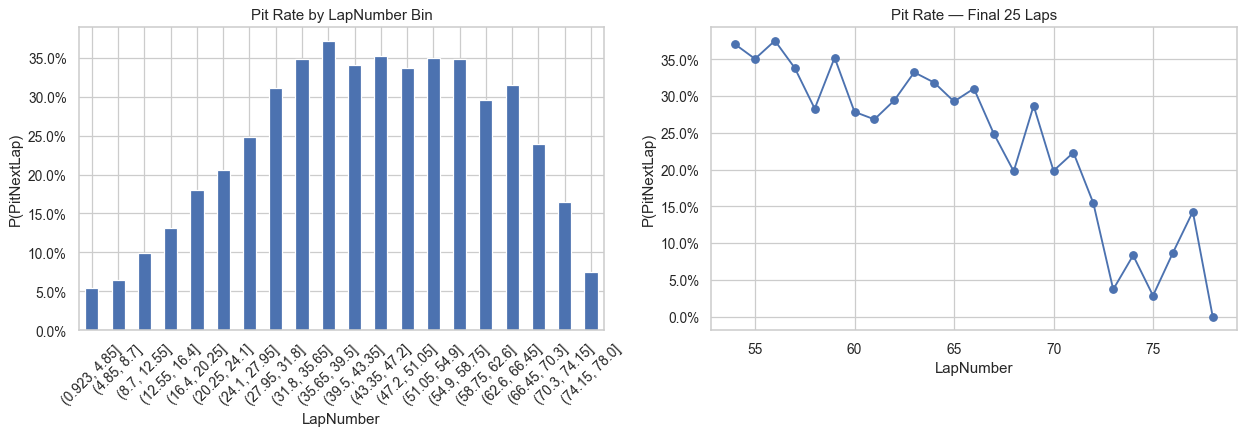

Opening lap (LapNumber ≤ 3) pit rate: 0.0503
All other laps pit rate:               0.2141


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

lap_bins = pd.cut(train['LapNumber'], bins=20)
train.groupby(lap_bins)[TARGET].mean().plot.bar(
    ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Pit Rate by LapNumber Bin')
axes[0].set_ylabel('P(PitNextLap)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].tick_params(axis='x', rotation=45)

# Closing laps
train.groupby('LapNumber')[TARGET].mean().iloc[-25:].plot(ax=axes[1], marker='o', color='#4C72B0')
axes[1].set_title('Pit Rate — Final 25 Laps')
axes[1].set_xlabel('LapNumber'); axes[1].set_ylabel('P(PitNextLap)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout(); plt.show()

print(f"Opening lap (LapNumber ≤ 3) pit rate: {train[train['LapNumber']<=3][TARGET].mean():.4f}")
print(f"All other laps pit rate:               {train[train['LapNumber']>3][TARGET].mean():.4f}")


**Observation → Hypothesis → Suggested Feature**

→ **Observation**: Lap 1 shows an anomalous pit spike (incident/safety car pits). Pit rate collapses in the final 5 laps.
→ **Hypothesis**: Tactical pits on lap 1 are forced/opportunistic (safety car window) and unrelated to tyre wear. Final-lap pit probability is near-zero regardless of tyre condition.
→ **Features**:
- `is_safety_car_lap` (binary: LapNumber ≤ 3 AND this is a pit lap — proxy for incident pits)
- `closing_lap_flag` (binary: RaceProgress > 0.90)


## 15. Correlations & Mutual Information

In [30]:
numeric_cols = train.select_dtypes(include=np.number).drop(columns=['id']).columns.tolist()
corr = train[numeric_cols].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("Pearson correlation with PitNextLap:")
print(corr.round(4).to_string())


Pearson correlation with PitNextLap:
TyreLife                  0.2735
LapNumber                 0.2671
Stint                     0.1982
RaceProgress              0.1855
Cumulative_Degradation   -0.1674
Year                      0.1253
PitStop                   0.0486
Position_Change           0.0462
LapTime (s)              -0.0341
Position                  0.0213
LapTime_Delta            -0.0049


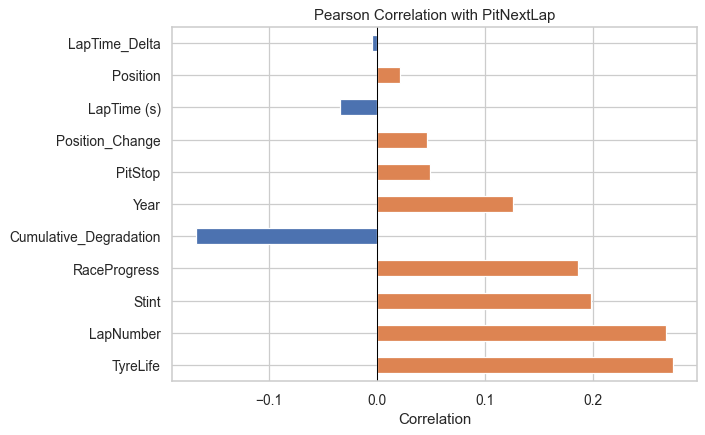

In [31]:
fig, ax = plt.subplots(figsize=(8,5))
colors = ['#DD8452' if v>0 else '#4C72B0' for v in corr]
corr.plot.barh(ax=ax, color=colors)
ax.set_title('Pearson Correlation with PitNextLap')
ax.set_xlabel('Correlation'); ax.axvline(0, color='black', lw=0.8)
plt.tight_layout(); plt.show()


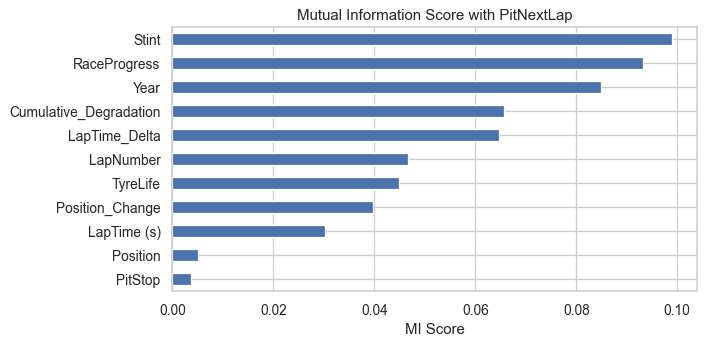


Mutual Information scores:
Stint                     0.09889
RaceProgress              0.09317
Year                      0.08496
Cumulative_Degradation    0.06570
LapTime_Delta             0.06469
LapNumber                 0.04673
TyreLife                  0.04495
Position_Change           0.03969
LapTime (s)               0.03026
Position                  0.00512
PitStop                   0.00374


In [32]:
features_mi = [c for c in numeric_cols if c != TARGET]
X_mi = train[features_mi].fillna(0)
y_mi = train[TARGET].astype(int)
mi = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_df = pd.Series(mi, index=features_mi).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,4))
mi_df.plot.barh(ax=ax, color='#4C72B0'); ax.invert_yaxis()
ax.set_title('Mutual Information Score with PitNextLap')
ax.set_xlabel('MI Score')
plt.tight_layout(); plt.show()

print("\nMutual Information scores:")
print(mi_df.round(5).to_string())


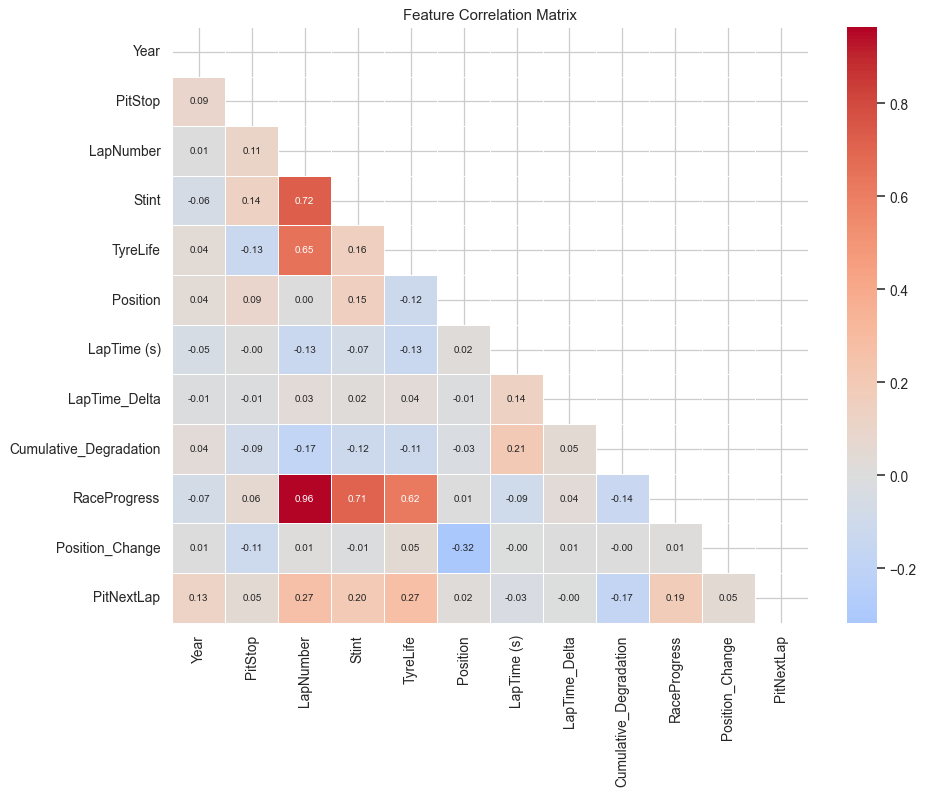

In [33]:
# Full correlation heatmap
fig, ax = plt.subplots(figsize=(11,9))
mask = np.triu(np.ones_like(train[numeric_cols].corr(), dtype=bool))
sns.heatmap(train[numeric_cols].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, linewidths=0.4, annot_kws={'size':8})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout(); plt.show()


**Observation → Hypothesis → Suggested Feature**

→ **Observation**: TyreLife and Cumulative_Degradation are positively correlated (both track stint age). Mutual information reveals non-linear relationships that Pearson misses — particularly for TyreLife and the pit windows.
→ **Hypothesis**: Tree-based models capture non-linear patterns natively; linear models need explicit non-linear features (squares, interactions, log transforms).
→ **Modeling decision**: Primary model = LightGBM / XGBoost. Add log-transformed and binned versions of TyreLife, Cumulative_Degradation for linear baselines.


## 16. Key Interaction Effects

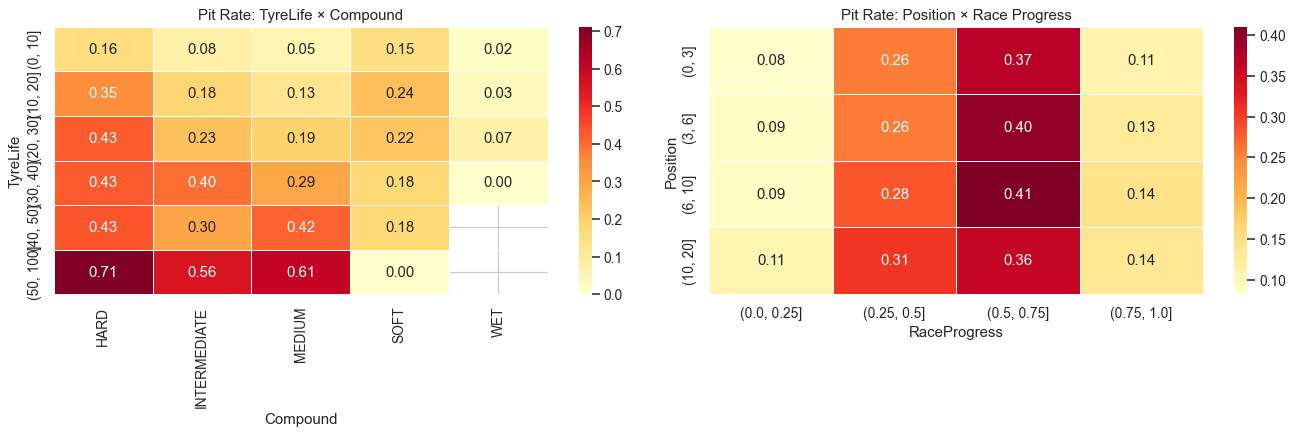

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# TyreLife × Compound pit rate heatmap
tl_bins = pd.cut(train['TyreLife'], bins=[0,10,20,30,40,50,100])
pivot1 = train.groupby([tl_bins,'Compound'])[TARGET].mean().unstack()
sns.heatmap(pivot1, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0], linewidths=0.5)
axes[0].set_title('Pit Rate: TyreLife × Compound')

# Position × RaceProgress pit rate heatmap
pos_bins = pd.cut(train['Position'], bins=[0,3,6,10,20])
rp_bins  = pd.cut(train['RaceProgress'], bins=[0,0.25,0.5,0.75,1.0])
pivot2 = train.groupby([pos_bins, rp_bins])[TARGET].mean().unstack()
sns.heatmap(pivot2, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1], linewidths=0.5)
axes[1].set_title('Pit Rate: Position × Race Progress')

plt.tight_layout(); plt.show()


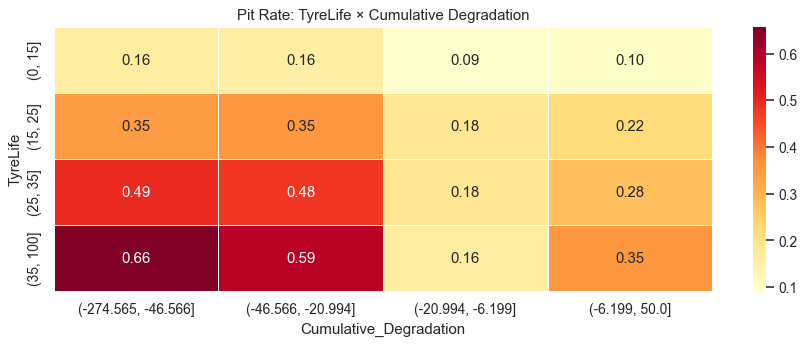

In [35]:
# TyreLife × Cumulative_Degradation
tl_bins2  = pd.cut(train['TyreLife'], bins=[0,15,25,35,100])
deg_bins2 = pd.qcut(train['Cumulative_Degradation'].clip(-300,50), q=4, duplicates='drop')
pivot3 = train.groupby([tl_bins2, deg_bins2])[TARGET].mean().unstack()

fig, ax = plt.subplots(figsize=(10,4))
sns.heatmap(pivot3, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Pit Rate: TyreLife × Cumulative Degradation')
plt.tight_layout(); plt.show()


**Observation → Hypothesis → Suggested Feature**

→ **Observation**: TyreLife + high Cumulative_Degradation is multiplicatively more predictive than either alone. A SOFT tyre at lap 20 with high degradation is a near-certain pit; a HARD tyre at lap 20 with low degradation is fine.
→ **Hypothesis**: The interaction of stint age AND current degradation level captures the "urgency" of a pit stop better than either alone.
→ **Features**:
- `tyre_life_x_deg_rate = TyreLife × (Cumulative_Degradation / TyreLife)` (= Cumulative_Degradation, but log-transformed interaction)
- `tyre_stress = tyre_life_ratio × degradation_rate` (compound-normalized interaction)
- Tree models capture these automatically; explicit features help linear/attention models.


## 17. Train / Test Distribution Check

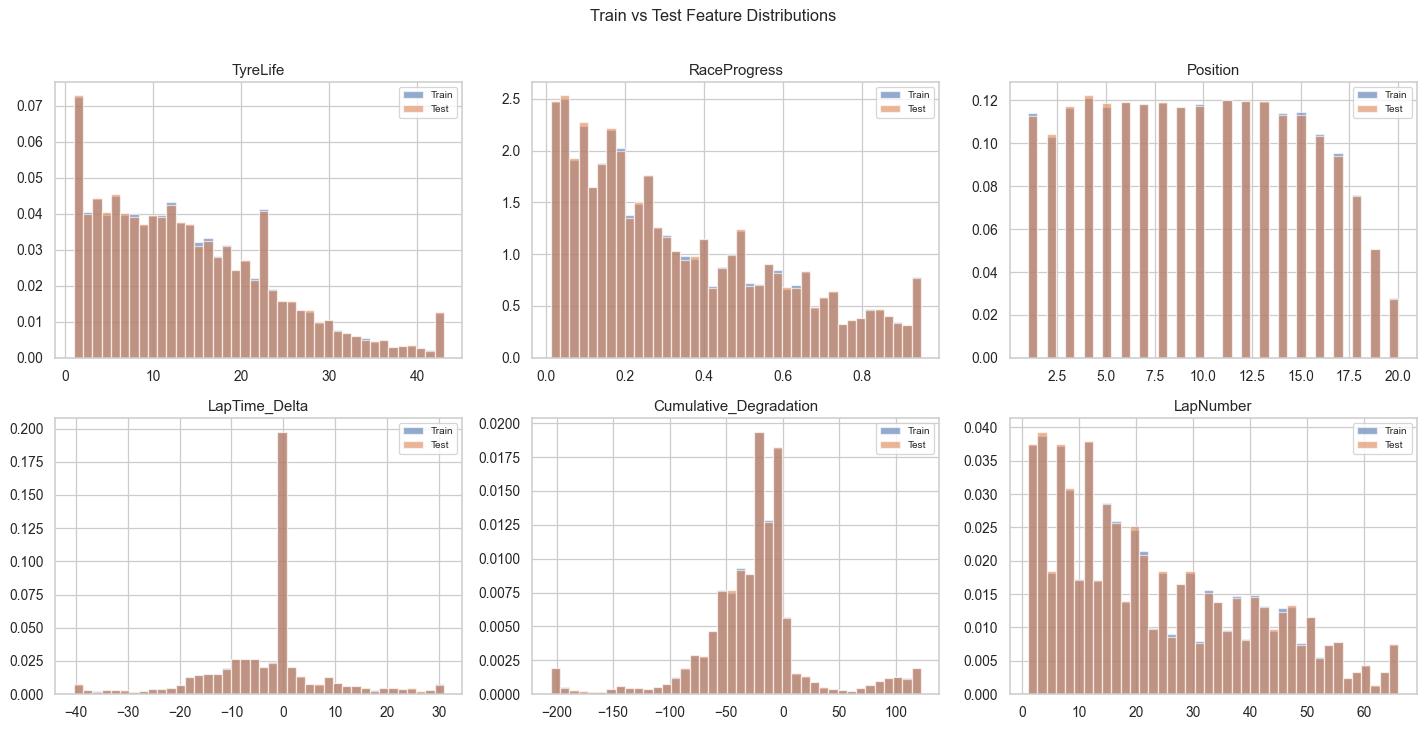

In [36]:
feats_check = ['TyreLife','RaceProgress','Position','LapTime_Delta','Cumulative_Degradation','LapNumber']
fig, axes = plt.subplots(2, 3, figsize=(16,8))

for ax, feat in zip(axes.flatten(), feats_check):
    lo = min(train[feat].quantile(0.01), test[feat].quantile(0.01))
    hi = max(train[feat].quantile(0.99), test[feat].quantile(0.99))
    train[feat].clip(lo, hi).hist(ax=ax, bins=40, alpha=0.6, density=True,
                                  label='Train', color='#4C72B0')
    test[feat].clip(lo, hi).hist(ax=ax, bins=40, alpha=0.6, density=True,
                                 label='Test', color='#DD8452')
    ax.set_title(feat); ax.legend(fontsize=8)

plt.suptitle('Train vs Test Feature Distributions', y=1.01, fontsize=13)
plt.tight_layout(); plt.show()


## Summary

All findings written to `docs/eda_insights.md`.

| Rank | Feature Theme | Priority |
|------|---------------|----------|
| 1 | TyreLife (raw + compound-normalized) | Critical |
| 2 | Cumulative_Degradation + degradation_rate | Critical |
| 3 | PitStop / just_pitted flag | Critical |
| 4 | RaceProgress + pit window flags | High |
| 5 | Compound encoding + expected stint | High |
| 6 | LapTime_Delta + trend | High |
| 7 | Position + undercut pressure | Medium |
| 8 | Stint number + is_final_stint | Medium |
| 9 | Driver target encoding | Medium |
| 10 | Race / Year target encoding | Medium |
| 11 | Opening / closing lap flags | Low |
| 12 | TyreLife × Degradation interaction | Low (linear models) |
